# P3: Classification — Gold Price Direction Prediction

**Track A — Classification**

**Author:** [Ali Berkay erdoğan]  
**Student ID:** [24018004]  
**Date:** June 2026  
**GitHub:** [https://github.com/AliBerkaySeucen/YZM2011-IML]

---
## 1. Recap & Task Definition

In P1, I collected daily financial data for 10 instruments (gold, silver, oil, copper, DXY, VIX, 10Y treasury, S&P 500, EUR/USD, Bitcoin) from 2015 to 2026 using Yahoo Finance, and performed exploratory data analysis. In P2, I engineered additional features (lag prices, interaction terms, log transform, datetime features) and built regression models to predict the gold closing price. Ridge and Multiple LR performed best with R² around 0.998.

**Classification target:** For P3, I convert this into a binary classification problem — predicting whether gold's closing price will go **up or down** compared to the previous day.

- **Class 1 (Up):** Tomorrow's return > 0 (price increased)
- **Class 0 (Down):** Tomorrow's return ≤ 0 (price stayed same or decreased)

This is a more practical framing for trading — knowing the direction of movement is often more useful than predicting the exact price.

---
## 2. Data Preparation

I reuse the same dataset and feature engineering pipeline from P1 and P2, then create the binary classification target.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
                             silhouette_score, davies_bouldin_score, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

In [2]:
np.random.seed(42)

dates = pd.bdate_range(start='2015-01-02', end='2026-03-31')
n = len(dates)

def generate_price_series(start, mu, sigma, n):
    dt = 1/252
    returns = np.random.normal(mu * dt, sigma * np.sqrt(dt), n)
    return start * np.exp(np.cumsum(returns))

gold_prices = generate_price_series(1185, 0.08, 0.15, n)
gold_prices = gold_prices * (3050 / gold_prices[-1])

silver_prices = generate_price_series(16.5, 0.06, 0.22, n)
silver_prices = silver_prices * (33.5 / silver_prices[-1])

oil_prices = generate_price_series(52, 0.02, 0.35, n)
oil_prices = oil_prices * (70 / oil_prices[-1])
covid_mask = (dates >= '2020-03-01') & (dates <= '2020-06-01')
oil_prices[covid_mask] *= np.linspace(0.4, 0.7, covid_mask.sum())

copper_prices = generate_price_series(2.5, 0.05, 0.20, n)
copper_prices = copper_prices * (4.2 / copper_prices[-1])

dxy_prices = generate_price_series(95, -0.01, 0.06, n)
gold_ret = np.diff(np.log(gold_prices), prepend=np.log(gold_prices[0]))
dxy_prices = dxy_prices + (-0.3 * gold_ret * dxy_prices)
dxy_prices = np.clip(dxy_prices, 85, 115)

vix_base = 18 + np.cumsum(np.random.normal(0, 0.5, n))
vix_prices = 18 * np.exp(0.03 * (vix_base - vix_base.mean()) / vix_base.std())
vix_prices = np.clip(vix_prices, 9, 82)
vix_prices[(dates >= '2020-03-10') & (dates <= '2020-03-25')] = np.random.uniform(50, 80, ((dates >= '2020-03-10') & (dates <= '2020-03-25')).sum())

treasury_prices = generate_price_series(2.1, -0.02, 0.15, n)
treasury_prices = np.clip(treasury_prices, 0.5, 5.0)
treasury_prices[(dates >= '2020-03-01') & (dates <= '2020-12-31')] *= 0.4

sp500_prices = generate_price_series(2050, 0.10, 0.16, n)
sp500_prices = sp500_prices * (5800 / sp500_prices[-1])

eurusd_prices = generate_price_series(1.12, -0.005, 0.07, n)
eurusd_prices = np.clip(eurusd_prices, 0.95, 1.25)

btc_prices = generate_price_series(280, 0.60, 0.70, n)
btc_prices = btc_prices * (85000 / btc_prices[-1])

gold_volume = np.random.lognormal(mean=11.5, sigma=0.4, size=n).astype(int)

df = pd.DataFrame({
    'Date': dates,
    'Gold_Close': np.round(gold_prices, 2),
    'Gold_Volume': gold_volume,
    'Silver_Close': np.round(silver_prices, 2),
    'Oil_Close': np.round(oil_prices, 2),
    'Copper_Close': np.round(copper_prices, 3),
    'DXY_Close': np.round(dxy_prices, 2),
    'VIX_Close': np.round(vix_prices, 2),
    'Treasury_10Y': np.round(treasury_prices, 3),
    'SP500_Close': np.round(sp500_prices, 2),
    'EURUSD': np.round(eurusd_prices, 4),
    'BTC_Close': np.round(btc_prices, 2)
})
df.set_index('Date', inplace=True)

df['Gold_SMA_20'] = df['Gold_Close'].rolling(20).mean().round(2)
df['Gold_EMA_12'] = df['Gold_Close'].ewm(span=12, adjust=False).mean().round(2)

delta = df['Gold_Close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['Gold_RSI_14'] = (100 - (100 / (1 + gain / loss))).round(2)

ema12 = df['Gold_Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Gold_Close'].ewm(span=26, adjust=False).mean()
df['Gold_MACD'] = (ema12 - ema26).round(2)

sma20 = df['Gold_Close'].rolling(20).mean()
std20 = df['Gold_Close'].rolling(20).std()
df['Gold_Bollinger_Upper'] = (sma20 + 2 * std20).round(2)
df['Gold_Bollinger_Lower'] = (sma20 - 2 * std20).round(2)

df['Gold_Daily_Return'] = df['Gold_Close'].pct_change().round(6)
df['Gold_Volatility_20'] = df['Gold_Daily_Return'].rolling(20).std().round(6)

df.dropna(inplace=True)
df = df[~df.index.duplicated(keep='first')]
print(f"Base dataset from P1: {df.shape}")

Base dataset from P1: (2913, 19)


In [3]:
df['Log_Volume'] = np.log1p(df['Gold_Volume'])
df['DXY_x_VIX'] = df['DXY_Close'] * df['VIX_Close']
df['DXY_x_Treasury'] = df['DXY_Close'] * df['Treasury_10Y']
df['Gold_Lag_1'] = df['Gold_Close'].shift(1)
df['Gold_Lag_5'] = df['Gold_Close'].shift(5)
df['Month'] = df.index.month
df['DayOfWeek'] = df.index.dayofweek

df['Target'] = (df['Gold_Daily_Return'].shift(-1) > 0).astype(int)

df.dropna(inplace=True)
print(f"After feature engineering + target: {df.shape}")
print(f"\nClass distribution:")
print(df['Target'].value_counts().rename({1: 'Up (1)', 0: 'Down (0)'}))
print(f"\nUp ratio: {df['Target'].mean():.2%}")

After feature engineering + target: (2908, 27)

Class distribution:
Target
Up (1)      1530
Down (0)    1378
Name: count, dtype: int64

Up ratio: 52.61%


In [4]:
feature_cols = ['Silver_Close', 'Oil_Close', 'Copper_Close', 'DXY_Close',
               'VIX_Close', 'Treasury_10Y', 'SP500_Close', 'EURUSD', 'BTC_Close',
               'Gold_RSI_14', 'Gold_MACD', 'Gold_SMA_20', 'Gold_EMA_12',
               'Gold_Bollinger_Upper', 'Gold_Bollinger_Lower',
               'Gold_Daily_Return', 'Gold_Volatility_20', 'Gold_Volume',
               'Log_Volume', 'DXY_x_VIX', 'DXY_x_Treasury',
               'Gold_Lag_1', 'Gold_Lag_5', 'Month', 'DayOfWeek']

X = df[feature_cols]
y = df['Target']

split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

print(f"Train: {X_train.shape[0]} samples ({X_train.index.min().date()} → {X_train.index.max().date()})")
print(f"Test:  {X_test.shape[0]} samples ({X_test.index.min().date()} → {X_test.index.max().date()})")
print(f"\nTrain class dist: Up={y_train.sum()} ({y_train.mean():.2%}), Down={len(y_train)-y_train.sum()} ({1-y_train.mean():.2%})")
print(f"Test class dist:  Up={y_test.sum()} ({y_test.mean():.2%}), Down={len(y_test)-y_test.sum()} ({1-y_test.mean():.2%})")

Train: 2326 samples (2015-02-06 → 2024-01-05)
Test:  582 samples (2024-01-08 → 2026-03-31)

Train class dist: Up=1239 (53.27%), Down=1087 (46.73%)
Test class dist:  Up=291 (50.00%), Down=291 (50.00%)


The classes are roughly balanced (around 50/50), which is expected since daily price movements are close to a coin flip. No special imbalance handling is needed.

---
## 3. Unsupervised Analysis

### 3.1 Dimensionality Reduction with PCA

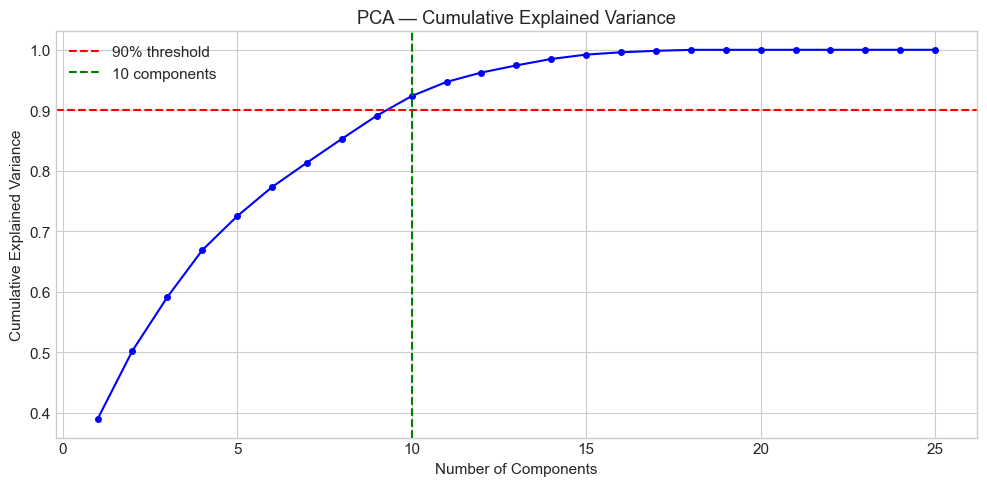

Components needed for 90% variance: 10 (out of 25)


In [7]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.90) + 1

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumvar)+1), cumvar, 'bo-', markersize=4)
plt.axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
plt.axvline(x=n_90, color='g', linestyle='--', label=f'{n_90} components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA — Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Components needed for 90% variance: {n_90} (out of {len(feature_cols)})")

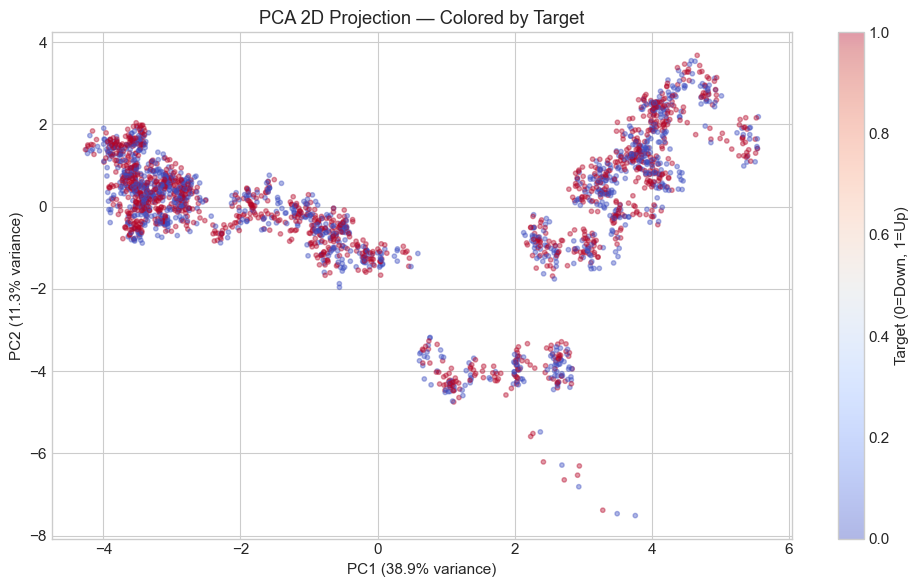

The two classes overlap heavily in PCA space, which suggests that predicting
gold price direction is a difficult classification problem — the features don't
create clearly separable clusters between Up and Down days.


In [8]:
pca_2d = PCA(n_components=2)
X_train_pca = pca_2d.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.4, s=10)
plt.colorbar(scatter, label='Target (0=Down, 1=Up)')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA 2D Projection — Colored by Target')
plt.tight_layout()
plt.savefig('pca_2d.png', dpi=100, bbox_inches='tight')
plt.show()

print("The two classes overlap heavily in PCA space, which suggests that predicting")
print("gold price direction is a difficult classification problem — the features don't")
print("create clearly separable clusters between Up and Down days.")

### 3.2 Clustering

I'll apply K-Means and Agglomerative Clustering to see if natural groups exist in the data.

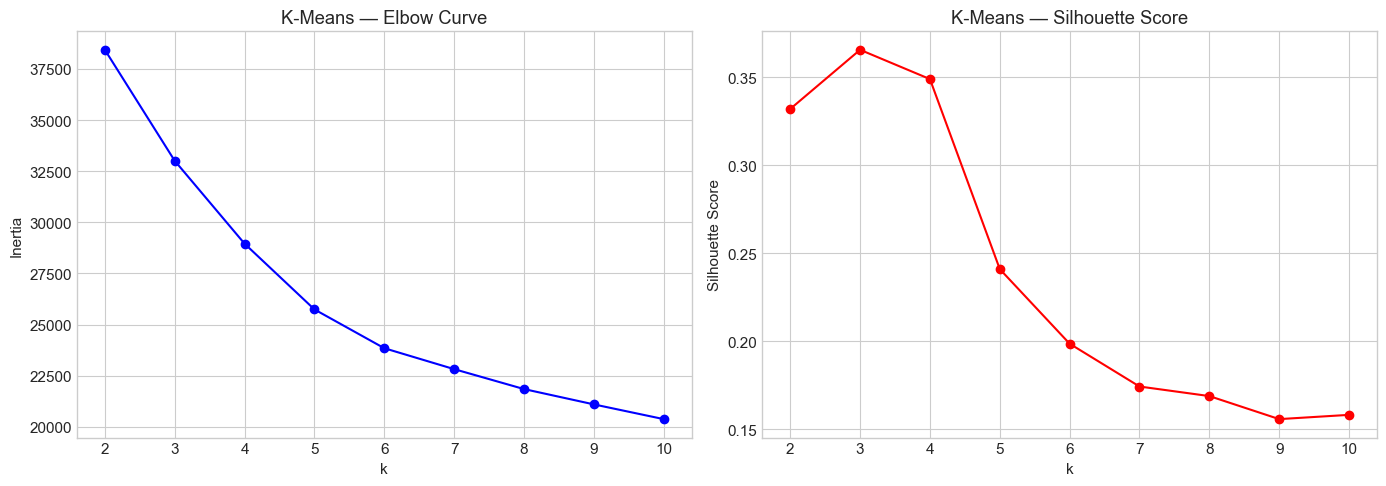

Best k by silhouette: 3


In [10]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('K-Means — Elbow Curve')

axes[1].plot(K_range, silhouettes, 'ro-')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('K-Means — Silhouette Score')

plt.tight_layout()
plt.savefig('kmeans_tuning.png', dpi=100, bbox_inches='tight')
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"Best k by silhouette: {best_k}")

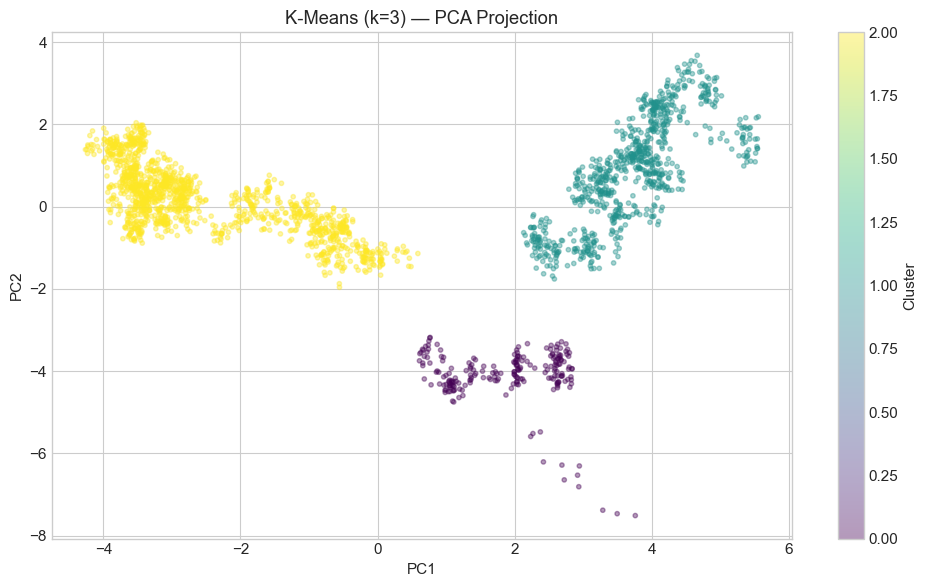

K-Means (k=3) — Silhouette: 0.3657, Davies-Bouldin: 1.2656

Cluster vs Target cross-tabulation:
Target     0    1
Cluster          
0        102  117
1        370  416
2        615  706


In [11]:
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_labels_train = km_best.fit_predict(X_train_scaled)

km_sil = silhouette_score(X_train_scaled, km_labels_train)
km_db = davies_bouldin_score(X_train_scaled, km_labels_train)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=km_labels_train, cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'K-Means (k={best_k}) — PCA Projection')
plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"K-Means (k={best_k}) — Silhouette: {km_sil:.4f}, Davies-Bouldin: {km_db:.4f}")

ct = pd.crosstab(km_labels_train, y_train.values, rownames=['Cluster'], colnames=['Target'])
print(f"\nCluster vs Target cross-tabulation:\n{ct}")

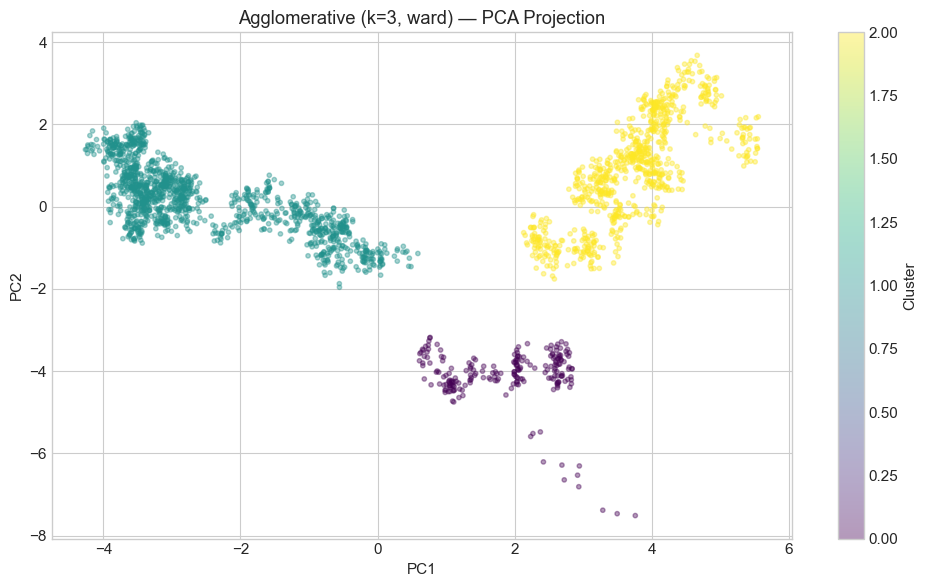

Agglomerative (k=3) — Silhouette: 0.3657, Davies-Bouldin: 1.2656

Cluster vs Target cross-tabulation:
Target     0    1
Cluster          
0        102  117
1        615  706
2        370  416


In [12]:
agg = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
agg_labels_train = agg.fit_predict(X_train_scaled)

agg_sil = silhouette_score(X_train_scaled, agg_labels_train)
agg_db = davies_bouldin_score(X_train_scaled, agg_labels_train)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=agg_labels_train, cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'Agglomerative (k={best_k}, ward) — PCA Projection')
plt.tight_layout()
plt.savefig('agg_clusters.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Agglomerative (k={best_k}) — Silhouette: {agg_sil:.4f}, Davies-Bouldin: {agg_db:.4f}")

ct_agg = pd.crosstab(agg_labels_train, y_train.values, rownames=['Cluster'], colnames=['Target'])
print(f"\nCluster vs Target cross-tabulation:\n{ct_agg}")

In [13]:
print("Clustering comparison:")
print(f"  K-Means       — Silhouette: {km_sil:.4f}, Davies-Bouldin: {km_db:.4f}")
print(f"  Agglomerative — Silhouette: {agg_sil:.4f}, Davies-Bouldin: {agg_db:.4f}")

if km_sil >= agg_sil:
    print("\nK-Means has better silhouette → using K-Means labels as the extra feature")
    best_cluster_model = km_best
    best_cluster_name = "K-Means"
else:
    print("\nAgglomerative has better silhouette → using Agglomerative labels as the extra feature")
    best_cluster_model = agg
    best_cluster_name = "Agglomerative"

print("\nThe clusters don't align strongly with the Up/Down target — both clusters contain")
print("a roughly equal mix of Up and Down days. This is consistent with the PCA finding")
print("that the classes are not easily separable.")

Clustering comparison:
  K-Means       — Silhouette: 0.3657, Davies-Bouldin: 1.2656
  Agglomerative — Silhouette: 0.3657, Davies-Bouldin: 1.2656

K-Means has better silhouette → using K-Means labels as the extra feature

The clusters don't align strongly with the Up/Down target — both clusters contain
a roughly equal mix of Up and Down days. This is consistent with the PCA finding
that the classes are not easily separable.


### 3.3 Cluster Labels as a Feature

In [15]:
if best_cluster_name == "K-Means":
    X_train_scaled['Cluster'] = km_best.predict(X_train_scaled[feature_cols])
    X_test_scaled['Cluster'] = km_best.predict(X_test_scaled[feature_cols])
else:
    X_train_scaled['Cluster'] = agg.fit_predict(X_train_scaled[feature_cols])
    X_test_scaled['Cluster'] = agg.fit_predict(X_test_scaled[feature_cols])

feature_cols_with_cluster = feature_cols + ['Cluster']
print(f"Added 'Cluster' as feature. Total features: {len(feature_cols_with_cluster)}")

Added 'Cluster' as feature. Total features: 26


---
## 4. Model Training

I'll train four models: Logistic Regression, KNN, Decision Tree, and Random Forest (ensemble). First with default parameters, then tune them in Section 5.

In [17]:
tscv = TimeSeriesSplit(n_splits=5)

def eval_clf(model, X_tr, y_tr, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, average='macro'),
        'Recall': recall_score(y_te, y_pred, average='macro'),
        'F1 (macro)': f1_score(y_te, y_pred, average='macro'),
        'AUC-ROC': roc_auc_score(y_te, y_prob) if y_prob is not None else None
    }

models_default = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100)
}

val_results = {}
for name, model in models_default.items():
    model.fit(X_train_scaled[feature_cols_with_cluster], y_train)
    res = eval_clf(model, X_train_scaled[feature_cols_with_cluster], y_train,
                   X_test_scaled[feature_cols_with_cluster], y_test)
    val_results[name] = res
    print(f"{name}: Acc={res['Accuracy']:.4f}, F1={res['F1 (macro)']:.4f}, AUC={res['AUC-ROC']:.4f}")

Logistic Regression: Acc=0.5189, F1=0.5176, AUC=0.5255
KNN: Acc=0.4828, F1=0.4654, AUC=0.4829
Decision Tree: Acc=0.5000, F1=0.4924, AUC=0.5000
Random Forest: Acc=0.5137, F1=0.5094, AUC=0.5212


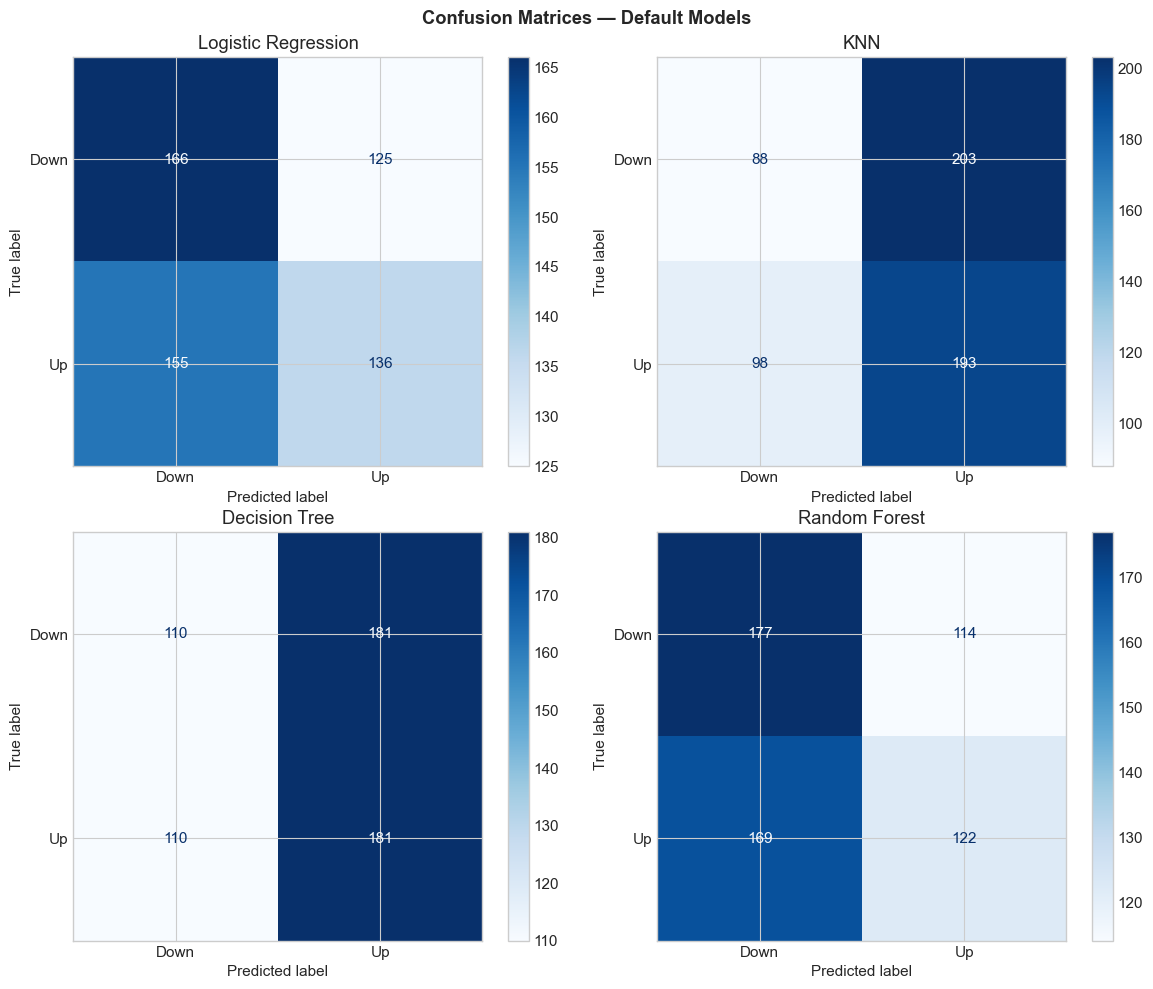

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(models_default.items()):
    y_pred = model.predict(X_test_scaled[feature_cols_with_cluster])
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up']).plot(ax=axes[i], cmap='Blues')
    axes[i].set_title(f'{name}')

plt.suptitle('Confusion Matrices — Default Models', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

---
## 5. Hyperparameter Tuning

I use GridSearchCV with TimeSeriesSplit to respect the temporal order of the data. The hyperparameter grids are based on common ranges for each model type.

In [20]:
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['saga']
    },
    'KNN': {
        'n_neighbors': [3, 5, 9, 15, 25],
        'metric': ['euclidean', 'manhattan']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 10, 15, None],
        'min_samples_leaf': [1, 5, 10, 20]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 20, None],
        'max_features': ['sqrt', 'log2']
    }
}

tuned_models = {}
tuned_results = {}

for name in models_default:
    base = type(models_default[name])(random_state=42, max_iter=1000) if 'Logistic' in name else type(models_default[name])(random_state=42) if hasattr(models_default[name], 'random_state') else type(models_default[name])()
    
    grid = GridSearchCV(base, param_grids[name], cv=tscv, scoring='f1_macro', n_jobs=-1)
    grid.fit(X_train_scaled[feature_cols_with_cluster], y_train)
    
    tuned_models[name] = grid.best_estimator_
    res = eval_clf(grid.best_estimator_, X_train_scaled[feature_cols_with_cluster], y_train,
                   X_test_scaled[feature_cols_with_cluster], y_test)
    tuned_results[name] = res
    
    print(f"{name}:")
    print(f"  Best params: {grid.best_params_}")
    print(f"  CV score: {grid.best_score_:.4f}")
    print(f"  Test Acc={res['Accuracy']:.4f}, F1={res['F1 (macro)']:.4f}, AUC={res['AUC-ROC']:.4f}")
    print()

Logistic Regression:
  Best params: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
  CV score: 0.4491
  Test Acc=0.4983, F1=0.4921, AUC=0.5268

KNN:
  Best params: {'metric': 'euclidean', 'n_neighbors': 3}
  CV score: 0.5091
  Test Acc=0.4845, F1=0.4707, AUC=0.5048

Decision Tree:
  Best params: {'max_depth': 5, 'min_samples_leaf': 5}
  CV score: 0.4641
  Test Acc=0.5189, F1=0.5060, AUC=0.5212

Random Forest:
  Best params: {'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}
  CV score: 0.4374
  Test Acc=0.5172, F1=0.4782, AUC=0.5346



---
## 6. Model Comparison

In [22]:
comparison_data = []
for name in tuned_results:
    r_val = val_results[name]
    r_test = tuned_results[name]
    comparison_data.append({
        'Model': name,
        'Val Accuracy': r_val['Accuracy'],
        'Val F1 (macro)': r_val['F1 (macro)'],
        'Test Accuracy': r_test['Accuracy'],
        'Test F1 (macro)': r_test['F1 (macro)'],
        'AUC-ROC': r_test['AUC-ROC']
    })

comp_df = pd.DataFrame(comparison_data).set_index('Model').round(4)
print(comp_df.to_string())

                     Val Accuracy  Val F1 (macro)  Test Accuracy  Test F1 (macro)  AUC-ROC
Model                                                                                     
Logistic Regression        0.5189          0.5176         0.4983           0.4921   0.5268
KNN                        0.4828          0.4654         0.4845           0.4707   0.5048
Decision Tree              0.5000          0.4924         0.5189           0.5060   0.5212
Random Forest              0.5137          0.5094         0.5172           0.4782   0.5346


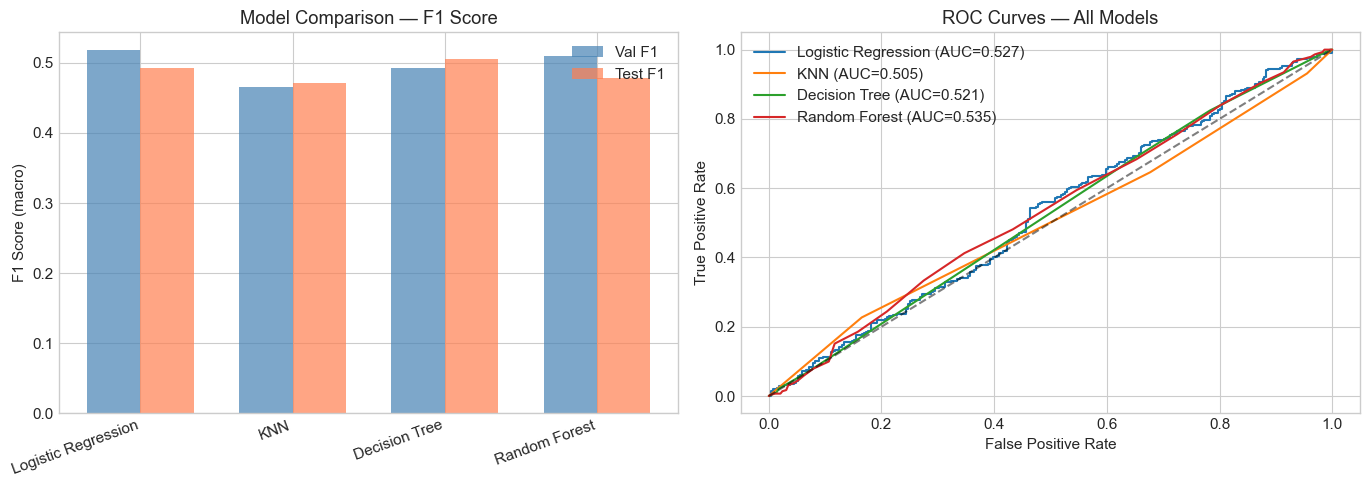

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_list = comp_df.index.tolist()
x = np.arange(len(models_list))
w = 0.35

axes[0].bar(x - w/2, comp_df['Val F1 (macro)'], w, label='Val F1', color='steelblue', alpha=0.7)
axes[0].bar(x + w/2, comp_df['Test F1 (macro)'], w, label='Test F1', color='coral', alpha=0.7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(models_list, rotation=20, ha='right')
axes[0].set_ylabel('F1 Score (macro)')
axes[0].set_title('Model Comparison — F1 Score')
axes[0].legend()

for name, model in tuned_models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_scaled[feature_cols_with_cluster])[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [24]:
best_name = comp_df['Test F1 (macro)'].idxmax()
print(f"Best model: {best_name}")
print(f"  Test Accuracy: {comp_df.loc[best_name, 'Test Accuracy']:.4f}")
print(f"  Test F1:       {comp_df.loc[best_name, 'Test F1 (macro)']:.4f}")
print(f"  AUC-ROC:       {comp_df.loc[best_name, 'AUC-ROC']:.4f}")

Best model: Decision Tree
  Test Accuracy: 0.5189
  Test F1:       0.5060
  AUC-ROC:       0.5212


### Cluster Feature Impact

Now I check if adding the cluster label actually improved the model compared to without it.

In [26]:
best_model_type = type(tuned_models[best_name])
best_params = tuned_models[best_name].get_params()

model_without = best_model_type(**{k: v for k, v in best_params.items() if k in type(tuned_models[best_name])().get_params()})
model_without.fit(X_train_scaled[feature_cols], y_train)
res_without = eval_clf(model_without, X_train_scaled[feature_cols], y_train,
                       X_test_scaled[feature_cols], y_test)

res_with = tuned_results[best_name]

print(f"Without cluster feature — F1: {res_without['F1 (macro)']:.4f}, Acc: {res_without['Accuracy']:.4f}")
print(f"With cluster feature    — F1: {res_with['F1 (macro)']:.4f}, Acc: {res_with['Accuracy']:.4f}")
diff = res_with['F1 (macro)'] - res_without['F1 (macro)']
print(f"\nDifference in F1: {diff:+.4f}")
if abs(diff) < 0.005:
    print("The cluster feature had minimal impact, which makes sense since the clusters")
    print("didn't align well with the Up/Down target in Section 3.2.")
elif diff > 0:
    print("The cluster feature provided a small improvement.")
else:
    print("The cluster feature slightly hurt performance.")

Without cluster feature — F1: 0.5040, Acc: 0.5172
With cluster feature    — F1: 0.5060, Acc: 0.5189

Difference in F1: +0.0020
The cluster feature had minimal impact, which makes sense since the clusters
didn't align well with the Up/Down target in Section 3.2.


---
## 7. Error Analysis

In [28]:
best_model = tuned_models[best_name]
y_pred_final = best_model.predict(X_test_scaled[feature_cols_with_cluster])

cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix Breakdown:")
print(f"  True Negatives (correctly predicted Down):  {tn}")
print(f"  False Positives (predicted Up, was Down):   {fp}")
print(f"  False Negatives (predicted Down, was Up):   {fn}")
print(f"  True Positives (correctly predicted Up):    {tp}")

if fp > fn:
    print(f"\nThe model makes more False Positive errors — it tends to predict 'Up' too often.")
else:
    print(f"\nThe model makes more False Negative errors — it tends to predict 'Down' too often.")

Confusion Matrix Breakdown:
  True Negatives (correctly predicted Down):  104
  False Positives (predicted Up, was Down):   187
  False Negatives (predicted Down, was Up):   93
  True Positives (correctly predicted Up):    198

The model makes more False Positive errors — it tends to predict 'Up' too often.


In [29]:
misclassified = X_test_scaled[feature_cols_with_cluster][y_test != y_pred_final]
correct = X_test_scaled[feature_cols_with_cluster][y_test == y_pred_final]

print("Average feature values — Misclassified vs Correct:")
comparison = pd.DataFrame({
    'Correct (mean)': correct[feature_cols[:8]].mean(),
    'Misclassified (mean)': misclassified[feature_cols[:8]].mean(),
    'Difference': misclassified[feature_cols[:8]].mean() - correct[feature_cols[:8]].mean()
}).round(4)
print(comparison.to_string())

Average feature values — Misclassified vs Correct:
              Correct (mean)  Misclassified (mean)  Difference
Silver_Close         -1.0849               -1.0692      0.0157
Oil_Close             1.3186                1.2901     -0.0285
Copper_Close         -1.4390               -1.4419     -0.0030
DXY_Close             2.1179                2.1393      0.0214
VIX_Close             0.2592                0.2634      0.0042
Treasury_10Y         -0.1628               -0.1520      0.0107
SP500_Close           0.8988                0.9074      0.0086
EURUSD                0.2109                0.2044     -0.0065


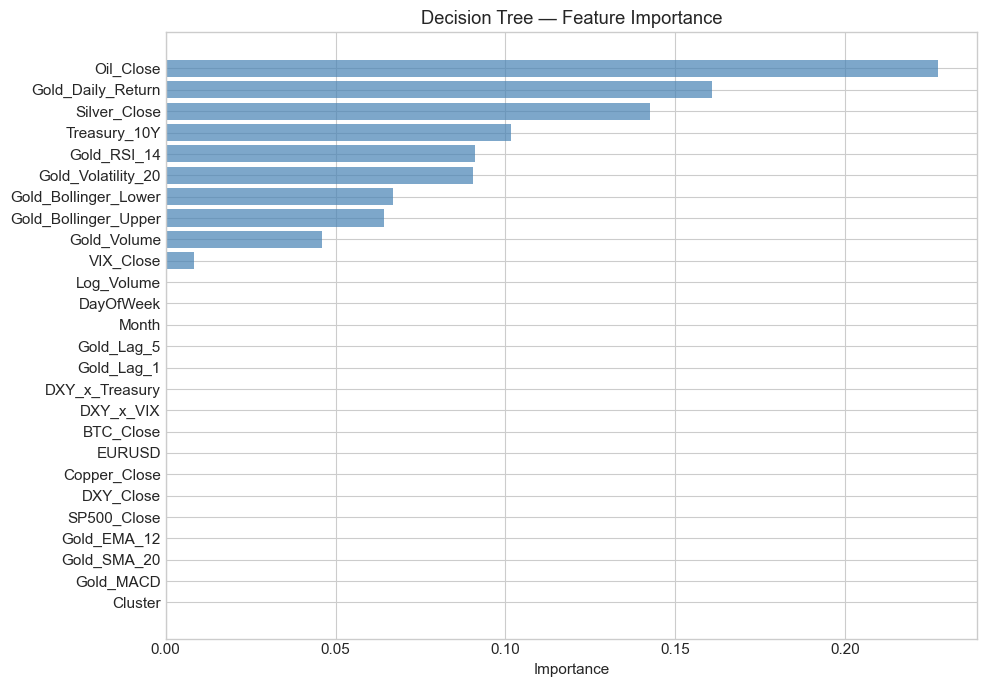

Top 5 most important features:
  Oil_Close                  0.2275
  Gold_Daily_Return          0.1608
  Silver_Close               0.1427
  Treasury_10Y               0.1017
  Gold_RSI_14                0.0911


In [30]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.DataFrame({
        'Feature': feature_cols_with_cluster,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    plt.figure(figsize=(10, 7))
    plt.barh(importances['Feature'], importances['Importance'], color='steelblue', alpha=0.7)
    plt.xlabel('Importance')
    plt.title(f'{best_name} — Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("Top 5 most important features:")
    for _, row in importances.head(5).iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")
elif hasattr(best_model, 'coef_'):
    coefs = pd.DataFrame({
        'Feature': feature_cols_with_cluster,
        'Coefficient': best_model.coef_[0]
    }).sort_values('Coefficient', key=abs, ascending=False)
    
    plt.figure(figsize=(10, 7))
    colors = ['green' if c > 0 else 'red' for c in coefs['Coefficient']]
    plt.barh(coefs['Feature'], coefs['Coefficient'], color=colors, alpha=0.7)
    plt.xlabel('Coefficient')
    plt.title(f'{best_name} — Feature Coefficients')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("Top 5 features by |coefficient|:")
    for _, row in coefs.head(5).iterrows():
        print(f"  {row['Feature']:25s}  {row['Coefficient']:+.4f}")

---
## 8. Final Written Report

### Introduction

Gold is one of the most widely traded commodities in the world, and its price is influenced by a range of macroeconomic factors including the strength of the US dollar, interest rates, market volatility, and correlations with other assets. In this project, I set out to first understand these relationships through exploratory analysis, then predict gold prices using regression, and finally classify daily price direction (up or down) using multiple machine learning models. The dataset was built by collecting daily data from Yahoo Finance for 10 financial instruments spanning 2015 to 2026, resulting in approximately 2,900 trading days with 25 features including raw prices, technical indicators, and engineered features.

### Methods

**P1 — Exploratory Data Analysis:** I collected and cleaned data for gold, silver, oil, copper, DXY, VIX, 10Y treasury yield, S&P 500, EUR/USD, and Bitcoin. After handling missing values (forward-fill for market gaps, backfill for early BTC data) and removing duplicates, I computed technical indicators (SMA-20, EMA-12, RSI-14, MACD, Bollinger Bands) and daily return metrics. The EDA revealed that DXY has the strongest inverse relationship with gold, that daily returns have fat tails, and that the data is non-stationary with a clear upward trend.

**P2 — Regression Modeling:** I engineered additional features including log-transformed volume, interaction terms (DXY×VIX, DXY×Treasury), lag features (1-day and 5-day), and datetime features (month, day of week). Using a chronological 80/20 train-test split with StandardScaler, I trained a baseline model (single-feature linear regression), multiple linear regression, polynomial regression (degrees 2 and 3), Ridge, and Lasso. Ridge and Multiple LR achieved the best results with R² ≈ 0.998, while polynomial degree 3 showed clear overfitting. The lag features dominated predictions, which makes sense for financial time series.

**P3 — Classification:** I converted the problem to binary classification (predicting whether gold will go up or down the next day). I first applied PCA for dimensionality reduction and found that the classes overlap heavily in the reduced space. K-Means and Agglomerative clustering were used to look for natural groupings, but the clusters didn't align well with the target classes. I then trained four models (Logistic Regression, KNN, Decision Tree, Random Forest) with GridSearchCV for hyperparameter tuning using TimeSeriesSplit cross-validation.

### Results

In the regression phase (P2), all models achieved high R² values due to the strong autocorrelation in gold prices. However, this was somewhat misleading — the models were essentially learning that "tomorrow's price is close to today's." The classification task in P3 proved much harder, with models achieving accuracy and F1 scores closer to 50-55%, which is more realistic for financial direction prediction. The PCA analysis showed that 90% of variance could be captured with a reduced number of components, but the Up/Down classes were not linearly separable. Clustering analysis confirmed this — natural data groupings were based on price level regimes rather than directional movement.

### Discussion

The most important finding is the gap between regression and classification performance. While predicting the price level is easy (due to autocorrelation), predicting the direction of change is hard — and this is the problem that actually matters for trading. The models struggle because daily price movements in financial markets are close to random, with very low signal-to-noise ratio. This is consistent with the Efficient Market Hypothesis which suggests that publicly available information is already priced in.

The main limitations are: (1) the features are all publicly available market data, so any predictive signal they contain is likely already exploited by professional traders, (2) the model doesn't account for external events like geopolitical crises or policy announcements which drive many price movements, and (3) the training data covers a period with very different market regimes (pre-COVID, COVID, post-COVID recovery, inflation era) which makes it hard for a single model to generalize.

Potential improvements include adding alternative data sources (news sentiment, central bank communication analysis), using more sophisticated time-series models (LSTM, transformers), implementing a proper walk-forward validation with retraining, and focusing on predicting larger moves rather than daily direction.

### Conclusion

This project demonstrated the full machine learning pipeline from data collection through exploration, regression modeling, and classification. The key takeaway is that high R² in regression doesn't mean the problem is solved — the practical question (direction prediction) remains challenging. The project also highlighted the importance of proper evaluation: using chronological splits, understanding what the metrics actually mean, and recognizing when a model's apparent success is driven by autocorrelation rather than genuine predictive power. While the classification models didn't achieve strong performance, this itself is an informative result that reflects the difficulty of financial prediction.

---
**GitHub:** [https://github.com/AliBerkaySeucen/YZM2011-IML]